In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns 
import numpy as np 

In [3]:
data = pd.read_csv('../data/cleaned_data.csv')
data.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,BMXBMI,LBXGH,DIQ010,LBXGLU,SBP_mean,LBDHDD,LBXSCR,ACR,diabetes_label,LBXGH_missing,HDL_missing,ACR_missing,LBXGLU_missing
0,109266.0,29.0,2.0,6.0,37.8,5.2,2.0,103.0,99.000000,56.0,0.63,0.152778,0,0,0,0,1
1,109267.0,21.0,2.0,2.0,28.6,5.6,2.0,103.0,121.333333,51.0,0.84,0.075926,0,1,1,1,1
2,109268.0,18.0,2.0,3.0,28.6,5.6,2.0,103.0,121.333333,51.0,0.84,0.075926,0,1,1,1,1
3,109271.0,49.0,1.0,3.0,29.7,5.6,2.0,103.0,107.000000,33.0,0.78,0.075000,0,0,0,0,0
4,109273.0,36.0,1.0,3.0,21.9,5.1,2.0,103.0,113.666667,42.0,0.92,0.040496,0,0,0,0,1


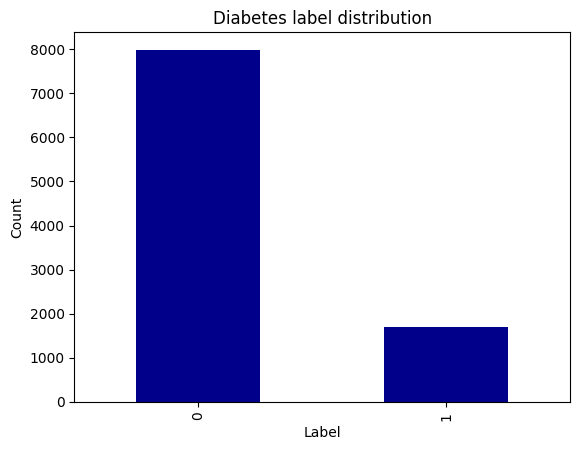

In [4]:
data["diabetes_label"].value_counts().plot(kind="bar", color = ['darkblue'])
plt.title("Diabetes label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

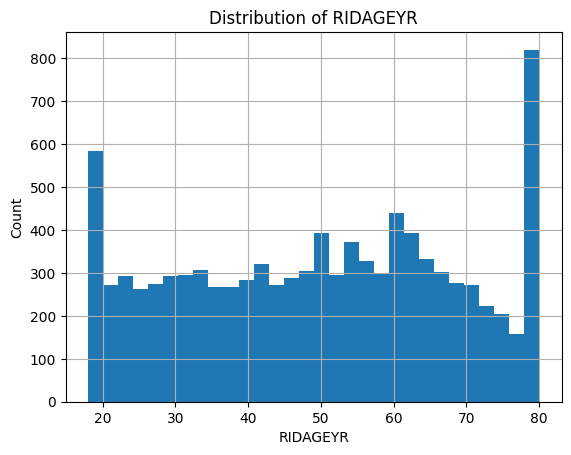

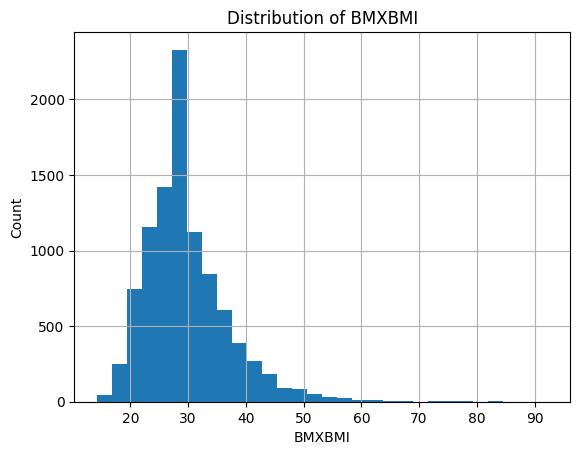

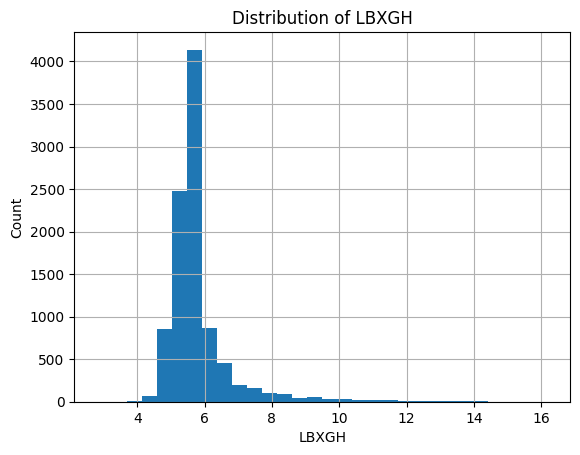

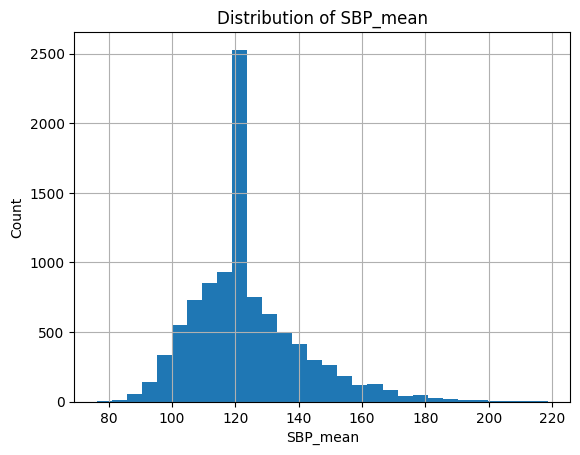

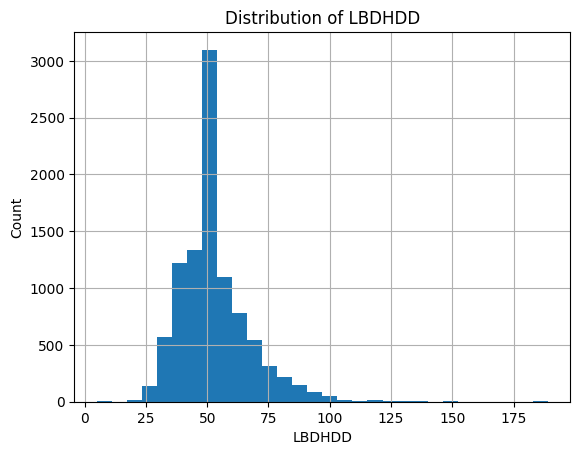

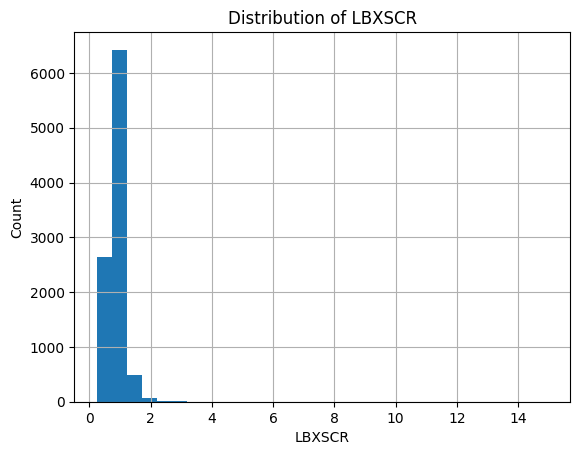

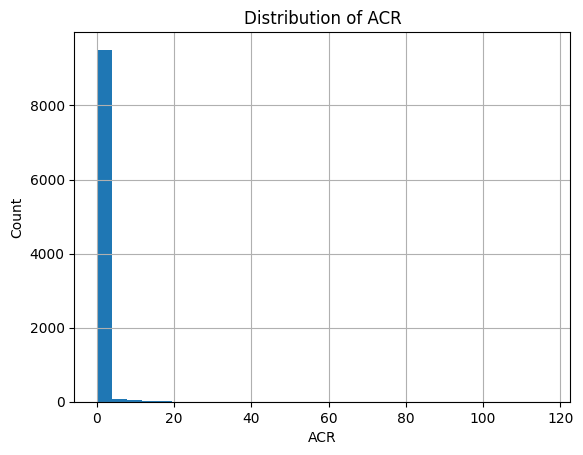

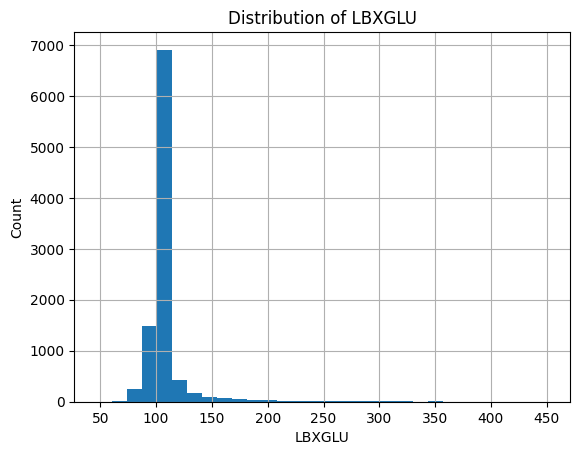

In [5]:
core_cols = ["RIDAGEYR","BMXBMI","LBXGH","SBP_mean","LBDHDD","LBXSCR","ACR","LBXGLU"]

for col in core_cols:
    data[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


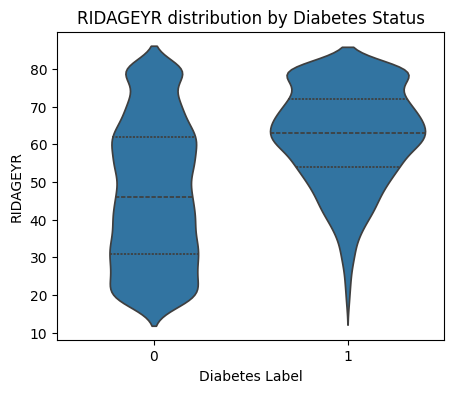

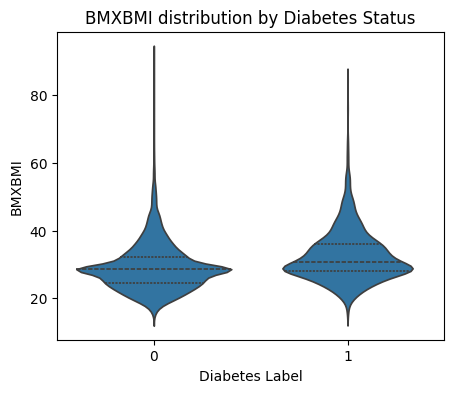

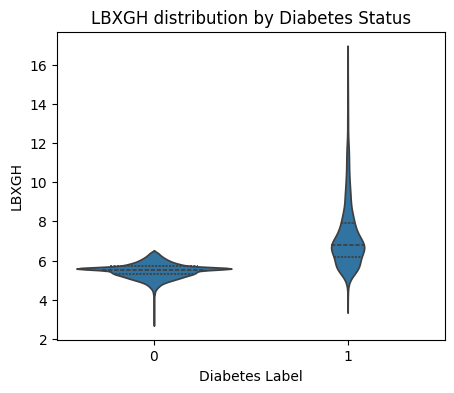

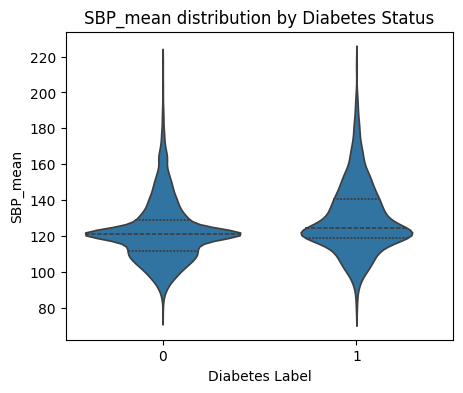

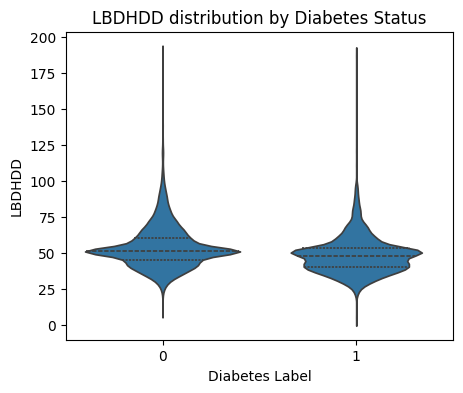

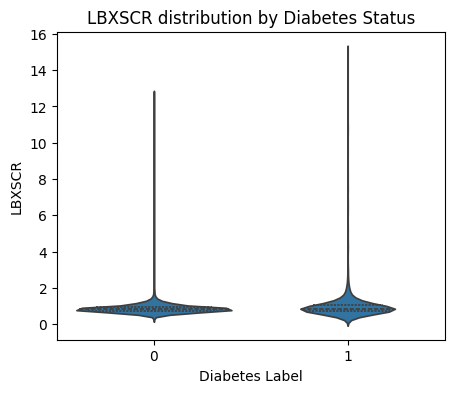

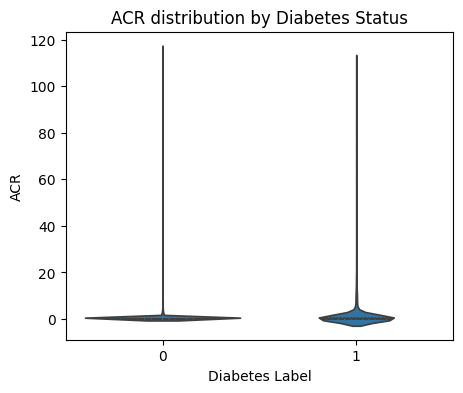

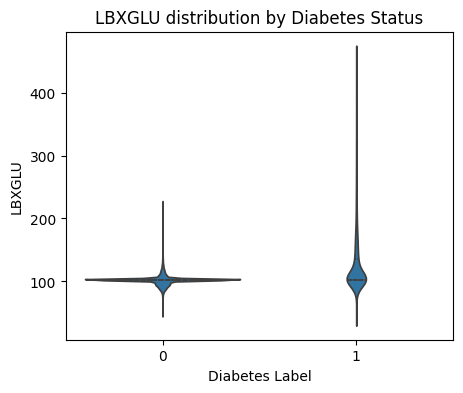

In [6]:
for col in core_cols:
    plt.figure(figsize=(5,4))
    sns.violinplot(x="diabetes_label", y=col, data=data, inner="quartile")
    plt.title(f"{col} distribution by Diabetes Status")
    plt.xlabel("Diabetes Label")
    plt.ylabel(col)
    plt.show()

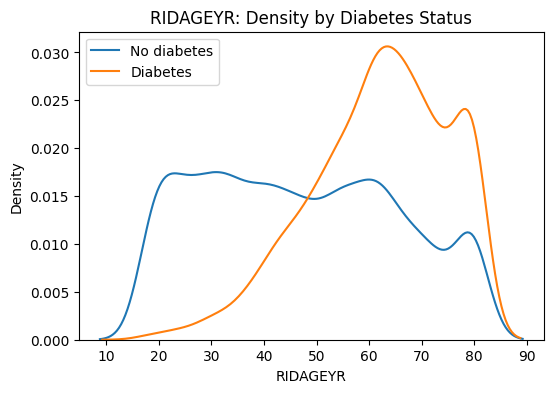

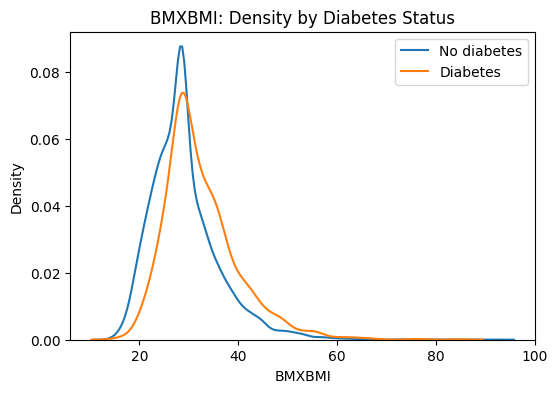

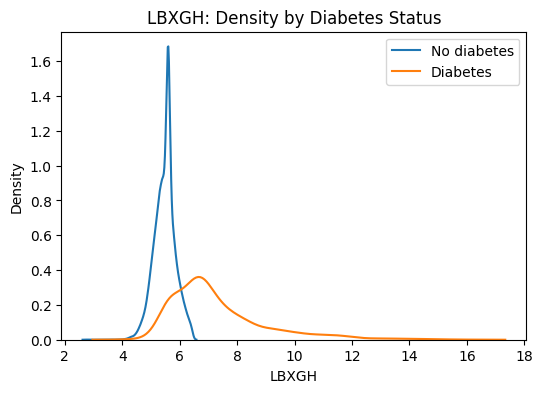

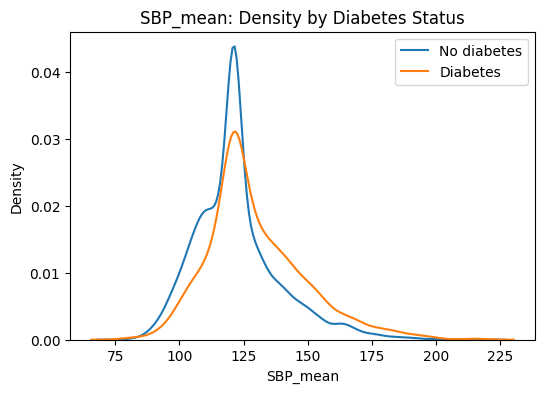

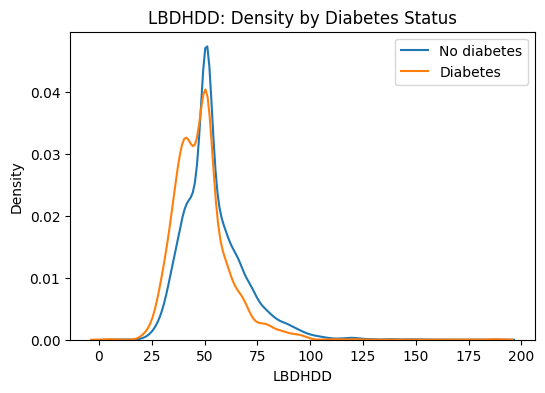

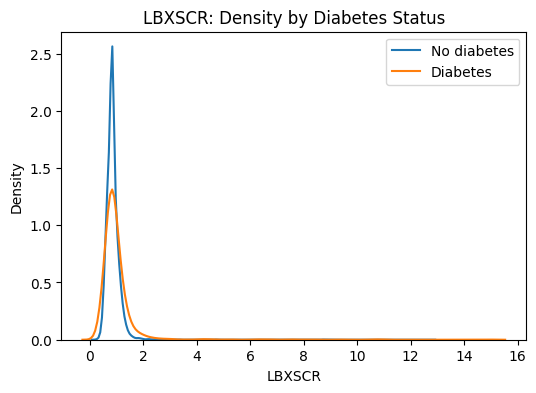

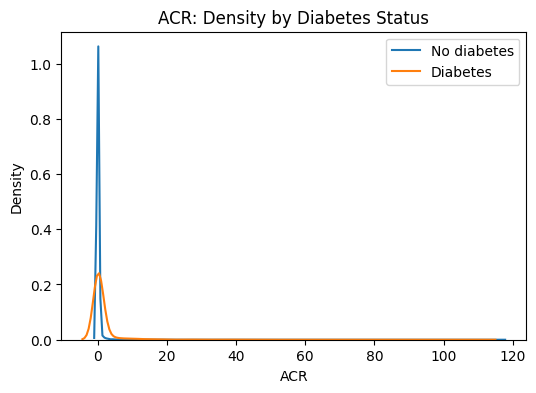

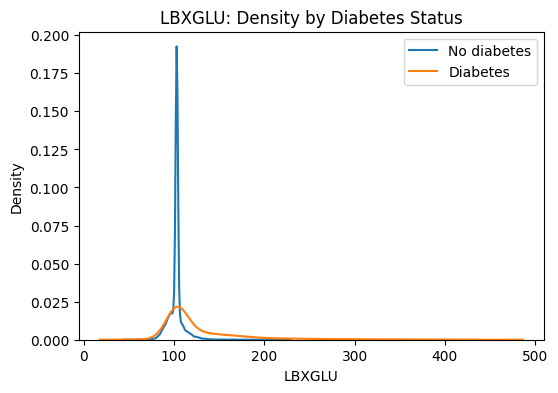

In [7]:
for col in core_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=data[data["diabetes_label"]==0][col], label="No diabetes")
    sns.kdeplot(data=data[data["diabetes_label"]==1][col], label="Diabetes")
    plt.title(f"{col}: Density by Diabetes Status")
    plt.xlabel(col)
    plt.legend()
    plt.show()

In [8]:
compare_cols = ["RIDAGEYR","BMXBMI","LBXGH","SBP_mean","LBDHDD","LBXSCR","ACR","LBXGLU"]

group_stats = data.groupby("diabetes_label")[compare_cols].agg(["mean","median","std"]).round(2)
group_stats


RIDAGEYR               BMXBMI              LBXGH               \
                   mean median    std   mean median   std  mean median   std   
diabetes_label                                                                 
0                 46.95   46.0  18.56  29.18  28.60  7.03  5.49    5.5  0.37   
1                 61.96   63.0  12.99  32.51  30.85  7.61  7.28    6.8  1.68   

               SBP_mean  ... LBDHDD LBXSCR                ACR               \
                   mean  ...    std   mean median   std  mean median   std   
diabetes_label           ...                                                 
0                122.45  ...  14.88   0.87   0.84  0.36  0.26   0.08  1.98   
1                129.65  ...  12.81   1.00   0.84  0.83  1.43   0.12  6.48   

                LBXGLU                
                  mean median    std  
diabetes_label                        
0               102.48  103.0   7.78  
1               129.64  103.0  51.84  

[2 rows x 24 columns]

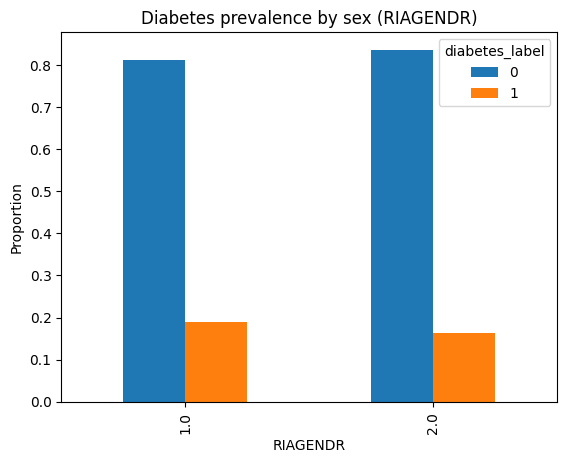

In [9]:
ct = pd.crosstab(data["RIAGENDR"], data["diabetes_label"], normalize="index")
ct.plot(kind="bar")
plt.title("Diabetes prevalence by sex (RIAGENDR)")
plt.xlabel("RIAGENDR")
plt.ylabel("Proportion")
plt.show()

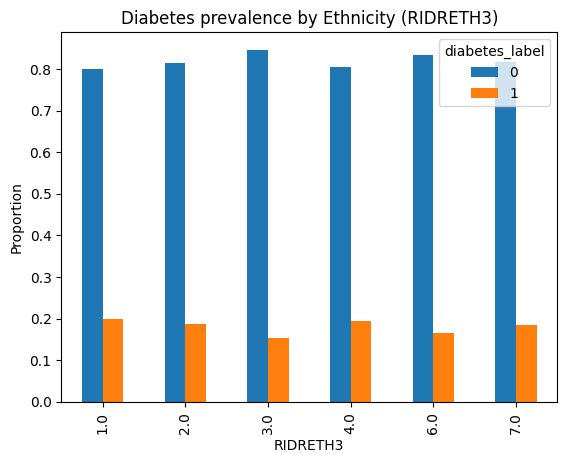

In [10]:
pd.crosstab(data["RIDRETH3"], data["diabetes_label"], normalize="index").round(3)
ct = pd.crosstab(data["RIDRETH3"], data["diabetes_label"], normalize="index")
ct.plot(kind="bar")
plt.title("Diabetes prevalence by Ethnicity (RIDRETH3)")
plt.xlabel("RIDRETH3")
plt.ylabel("Proportion")
plt.show()

In [11]:
missing_features = ["LBXGH_missing","HDL_missing","LBXGLU_missing","ACR_missing"]

data[missing_features].mean().sort_values(ascending=False).round(3)

LBXGLU_missing    0.569
HDL_missing       0.144
LBXGH_missing     0.127
ACR_missing       0.099
dtype: float64